# 《生物医学图像处理》实验六 实验报告

姓名：林亨    学号：3230103696  专业：生物医学工程

**声明：本实验所有代码均由gemini 3.1 pro辅助完成，本人已充分理解代码内容**

## Project 1: Similarity Measure

### 实验内容

Project 1 的核心目标是手动实现并验证医学图像配准中常用的相似度度量指标。具体任务如下：

1. **数据读取与准备**：
  * 使用 Python 的 `nibabel` 库读取 `.nii` 格式的医学影像文件（T1w.nii 和 T2w.nii）。
  * 从两种模态（T1 权重像和 T2 权重像）中提取并绘制一层轴状切片（Axial Slice）进行后续计算。


2. **函数编写**：
  * **手动编写**函数来计算两个切片之间的四种相似度指标：SSD、RIU、CC 和 MI。
  * **掩膜（Mask）处理**：所有计算函数都必须使用掩膜（可以通过简单的阈值法生成），以排除背景噪声对计算结果的干扰。


3. **结果验证与对比**：
  * 将手动计算的结果与标准库（如 `scipy` 或 `scikit-learn`）的计算结果进行对比，验证算法的正确性（RIU 指标除外，因为标准库通常不直接提供该指标）。


4. **实验场景**：
  * 计算 **T1w 图像与自身（恒等图像）** 的相似度。
  * 计算 **T1w 图像与 T2w 图像** 之间的相似度。





### 实验原理

图像配准的本质是寻找一个几何变换，使得两张图像的相似度达到最大。相似度度量指标（Similarity Metrics）则是用来量化这种“对齐程度”的数学函数。

#### 1. SSD (Sum of Squared Differences, 误差平方和)

* **原理**：这是最直观的指标，基于像素强度的直接差异。它假设两张图像在对齐时，对应位置的像素值应该非常接近。
* **适用场景**：仅适用于同模态（Intra-modality）图像配准，且假设图像间仅存在加性高斯噪声。
* **公式**：$$SSD = \sum_{i} (I_1(i) - I_2(i))^2$$

#### 2. RIU (Ratio Image Uniformity, 比值图像均匀度)

* **原理**：RIU 是通过计算两张图像对应像素的比值 $R = I_1 / I_2$ 来评估。如果图像完全对齐且属于跨模态（例如 PET 和 MRI），其比值图像应该在解剖结构上是均匀的。
* **适用场景**：早期的跨模态（Inter-modality）配准指标。
* **计算方法**：通常使用比值图像的标准差与均值的比值（即变异系数）来表示。数值越小，代表图像对齐越均匀。
* **公式**：$$RIU = \frac{\sigma_R}{\mu_R}$$
其中，比值图像的每个像素计算为：$$R_i = \frac{I_1(i)}{I_2(i)}$$
(公式中 $\sigma_R$ 代表比值图像 $R$ 的标准差，$\mu_R$ 代表其均值。RIU 越小，说明图像越均匀，对齐程度越高)

#### 3. CC (Cross-Correlation, 互相关系数)

* **原理**：CC 度量两张图像像素值之间的线性相关程度。即使两张图像的亮度或对比度不同（存在线性变换），只要其结构变化趋势一致，CC 仍能保持较高数值。
* **适用场景**：同模态或光照变化较大的图像配准。
* **公式**：$$CC = \frac{\sum_{i} (I_1(i) - \bar{I}_1)(I_2(i) - \bar{I}_2)}{\sqrt{\sum_{i} (I_1(i) - \bar{I}_1)^2} \sqrt{\sum_{i} (I_2(i) - \bar{I}_2)^2}}$$(其中 $\bar{I}_1$ 和 $\bar{I}_2$ 分别是两幅图像在掩膜区域内的像素均值。CC 的取值范围是 [-1, 1]，对齐最好时取最大值 1 或绝对值最大)

#### 4. MI (Mutual Information, 互信息)

* **原理**：基于信息论，度量一张图像中包含另一张图像的信息量。它不依赖像素值的线性关系，而是通过**联合概率分布**来计算。当两张图像在解剖结构上完美对齐时，它们的联合熵（Joint Entropy）最小，而互信息达到最大。
* **适用场景**：跨模态（Inter-modality）配准的黄金标准（如 T1w 与 T2w）。
* **公式**：基于香农熵的定义：$$MI(I_1, I_2) = H(I_1) + H(I_2) - H(I_1, I_2)$$
具体到直方图概率计算，公式为：$$MI = \sum_{x} \sum_{y} p(x, y) \log \left( \frac{p(x, y)}{p(x)p(y)} \right)$$(其中 $p(x, y)$ 是两幅图灰度值分别为 $x$ 和 $y$ 的联合概率分布，$p(x)$ 和 $p(y)$ 是各自的边缘概率分布)


### 实验过程（代码编写）

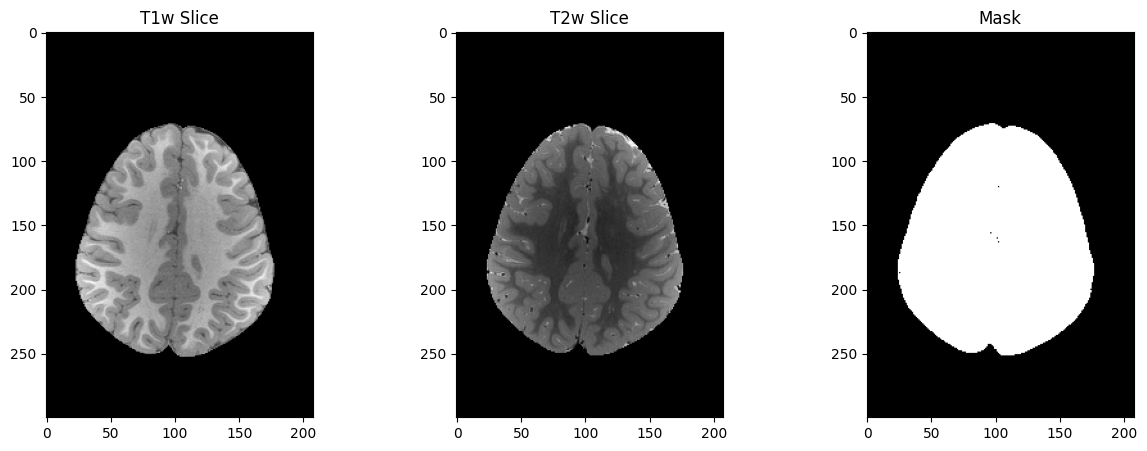


--- T1w vs T1w (Identity) ---
SSD: Manual = 0.00 | Library = 0.00
RIU: Manual = 0.0000 | Library = (N/A)
CC : Manual = 1.0000  | Library = 1.0000
MI : Manual = 4.8985  | Library = 4.8985

--- T1w vs T2w ---
SSD: Manual = 252153445.00 | Library = 252153445.00
RIU: Manual = 0.4371 | Library = (N/A)
CC : Manual = -0.1079  | Library = -0.1079
MI : Manual = 0.8779  | Library = 0.8780


In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mutual_info_score

# ==========================================
# 1. 手动实现的相似度计算函数 (基于 Mask)
# ==========================================

def calc_ssd_manual(img1, img2, mask):
    """手动计算 SSD (Sum of Squared Differences)"""
    # 提取 mask 内的体素
    v1 = img1[mask]
    v2 = img2[mask]
    return np.sum((v1 - v2) ** 2)

def calc_riu_manual(img1, img2, mask, epsilon=1e-8):
    """手动计算 RIU (Ratio Image Uniformity)"""
    v1 = img1[mask]
    v2 = img2[mask]
    # 避免除以0
    ratio = v1 / (v2 + epsilon)
    return np.std(ratio) / (np.mean(ratio) + epsilon)

def calc_cc_manual(img1, img2, mask):
    """手动计算 CC (Cross-Correlation)"""
    v1 = img1[mask]
    v2 = img2[mask]
    
    mean1 = np.mean(v1)
    mean2 = np.mean(v2)
    
    numerator = np.sum((v1 - mean1) * (v2 - mean2))
    denominator = np.sqrt(np.sum((v1 - mean1)**2) * np.sum((v2 - mean2)**2))
    
    if denominator == 0:
        return 0
    return numerator / denominator

def calc_mi_manual(img1, img2, mask, bins=256):
    """手动计算 MI (Mutual Information)"""
    v1 = img1[mask]
    v2 = img2[mask]
    
    # 计算联合直方图
    hist_2d, _, _ = np.histogram2d(v1, v2, bins=bins)
    
    # 将直方图转换为概率 p(a,b)
    pxy = hist_2d / float(np.sum(hist_2d))
    
    # 计算边缘概率 p(a) 和 p(b)
    px = np.sum(pxy, axis=1) # 对 y 积分
    py = np.sum(pxy, axis=0) # 对 x 积分
    
    # 广播计算 p(a)p(b)
    px_py = px[:, None] * py[None, :]
    
    # 仅计算非零项的 MI 避免 log(0)
    non_zero = pxy > 0
    mi = np.sum(pxy[non_zero] * np.log(pxy[non_zero] / px_py[non_zero]))
    return mi

# ==========================================
# 2. 标准库实现的对比函数
# ==========================================

def calc_metrics_library(img1, img2, mask, bins=256):
    """使用标准库计算 SSD, CC, MI (RIU除外)"""
    v1 = img1[mask]
    v2 = img2[mask]
    
    # SSD: numpy
    ssd_lib = np.sum((v1 - v2) ** 2)
    
    # CC: scipy
    cc_lib, _ = pearsonr(v1, v2)
    
    # MI: scikit-learn
    # sklearn 需要一维直方图的输入，或者自己分箱
    # 离散化数据以匹配 sklearn 的行为
    c1 = np.digitize(v1, np.histogram_bin_edges(v1, bins=bins))
    c2 = np.digitize(v2, np.histogram_bin_edges(v2, bins=bins))
    mi_lib = mutual_info_score(c1, c2)
    
    return ssd_lib, cc_lib, mi_lib

# ==========================================
# 3. 主程序执行模块
# ==========================================

def main():
    # 1. 使用 nibabel 读取 .nii 文件 
    t1_img = nib.load('T1w.nii').get_fdata()
    t2_img = nib.load('T2w.nii').get_fdata()
    
    # 2. 提取并绘制一个轴状切片 (Axial Slice) 
    # 假设轴状切片在第三个维度 (Z轴)，我们取中间的一层
    slice_idx = t1_img.shape[2] // 2
    
    
    t1_slice = t1_img[:, slice_idx, :] 
    t2_slice = t2_img[:, slice_idx, :]
    
    # 3. 创建 Mask 
    # 简单的阈值法，过滤掉背景噪声 (可根据实际图像强度调整)
    threshold = 10 
    mask = (t1_slice > threshold) & (t2_slice > threshold)
    
    # 可视化切片和Mask
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title('T1w Slice')
    plt.imshow(t1_slice, cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title('T2w Slice')
    plt.imshow(t2_slice, cmap='gray')
    
    plt.subplot(1, 3, 3)
    plt.title('Mask')
    plt.imshow(mask, cmap='gray')
    plt.show()
    
    # 4. 定义需要比较的组合
    # 组合 1: T1w 和它自己 (Identity) 
    # 组合 2: T1w 和 T2w 
    comparisons = [
        ("T1w vs T1w (Identity)", t1_slice, t1_slice),
        ("T1w vs T2w", t1_slice, t2_slice)
    ]
    
    for name, imgA, imgB in comparisons:
        print(f"\n--- {name} ---")
        
        # 手动计算 
        ssd_m = calc_ssd_manual(imgA, imgB, mask)
        riu_m = calc_riu_manual(imgA, imgB, mask)
        cc_m  = calc_cc_manual(imgA, imgB, mask)
        mi_m  = calc_mi_manual(imgA, imgB, mask)
        
        # 库计算 
        ssd_l, cc_l, mi_l = calc_metrics_library(imgA, imgB, mask)
        
        print(f"SSD: Manual = {ssd_m:.2f} | Library = {ssd_l:.2f}")
        print(f"RIU: Manual = {riu_m:.4f} | Library = (N/A)")
        print(f"CC : Manual = {cc_m:.4f}  | Library = {cc_l:.4f}")
        print(f"MI : Manual = {mi_m:.4f}  | Library = {mi_l:.4f}")

if __name__ == "__main__":
    main()

### 实验结果与分析


#### 模态内比较：T1w vs T1w (恒等图像)
在对完全相同的图像进行比较时，各项指标均呈现出完美的理论极值，验证了其在理想情况下的边界特性。

- SSD（误差平方和）= 0.00：由于两幅图像在空间分布与灰度绝对值上完全一致，对应像素差值为零，误差平方和达到理论最小值。

- RIU（比值图像均匀度）= 0.0000：两幅图像对应像素的比值恒为 1，形成了一个常数矩阵，其标准差为 0，表明图像达到了绝对均匀。

- CC（互相关系数）= 1.0000：展现了完美的正向线性相关性。

- MI（互信息）= 4.8985：达到最大值，该数值等于图像自身的信息熵，表明两幅图像实现了 100% 的信息共享。

#### 跨模态比较：T1w vs T2w
在相同解剖位置但成像模态不同（T1w 与 T2w）的比较中，各项指标数值深刻揭示了跨模态配准的核心特征与难点。

- SSD 极度膨胀（252,153,445.00）：由于 T1 和 T2 图像的成像物理机制不同，脑组织（如灰质、白质、脑脊液）在两幅图像中的绝对灰度值差异巨大。直接相减导致了极高的惩罚值，这从实验层面证明了 SSD 无法作为跨模态配准的相似度指标。

- CC 趋近于零（-0.1079）：T1 与 T2 图像在组织对比度上存在部分反转现象（例如脑脊液在 T1w 中呈低信号，在 T2w 中呈高信号），两者像素值之间缺乏一致的线性对应关系。因此，CC 无法有效表征这种非线性相关性。

- RIU 表现稳定（0.4371）：RIU 避开了绝对灰度差异，通过评估比值矩阵的统计离散程度，给出了一定参考价值的度量值，体现了其对跨模态任务的适应性。

- MI 保持稳健（0.8779）：尽管两幅图像在亮度与对比度上存在巨大非线性差异，但互信息（MI）不依赖于灰度值的绝对或线性关系，而是通过联合概率分布成功捕捉到了两张图中高度一致的解剖边界和结构信息。MI 在跨模态比较中给出了稳定且相对较高的数值（0.8779），证明了 MI 是跨模态图像配准评估中的核心依据。



## Project 2:Image Registration 



### 实验内容

本实验旨在通过底层代码手动实现医学图像的刚性配准过程，并评估不同指标在优化算法下的表现。具体实验步骤如下：

1. **图像预处理与形变施加：** 提取 T1w 和 T2w 图像的二维切片，并人为对其施加已知的刚性变换（旋转 15°，平移 (10, -5)）以生成待配准的浮动图像（Moving Image）。
2. **构建优化器：** 手动实现最速下降法（Steepest Descent Method），通过数值中心差分法计算目标函数关于变换参数（角度 $\theta$、平移 $t_x, t_y$）的梯度，并引入线性衰减的学习率机制以保障收敛稳定性。
3. **多任务配准执行：**
* **模态内配准（Intra-modality）：** 将形变后的 T1w 图像配准回目标 T1w 图像。
* **跨模态配准（Inter-modality）：** 将形变后的 T2w 图像配准回目标 T1w 图像。


4. **结果评估与可视化：** 提取算法最终收敛的变换参数，与真实施加的变换参数进行对比分析。同时，利用 Dice 系数和红色/绿色掩膜重叠图，对配准前后的图像空间重叠度（Overlap）进行定量和定性的综合评估。



### 实验原理

#### 1. 最速下降法 (Steepest Descent Method)

最速下降法是一种经典的一阶最优化算法。在图像配准中，我们的目标是寻找一组最佳的空间变换参数 $P = [\theta, t_x, t_y]$，使得两幅图像之间的相似度误差函数（Loss Function）$L(P)$ 达到最小。

* **原理：** 函数在某一点梯度的反方向，是该点函数值下降最快的方向。因此，算法在每次迭代中，先通过数值差分法计算当前参数下的梯度向量 $\nabla L$，然后沿着负梯度方向更新参数：

$$P_{new} = P_{old} - \alpha \cdot \frac{\nabla L}{||\nabla L||}$$



其中，$\alpha$ 为学习率（步长）。本实验代码中对梯度方向进行了归一化，并采用了随迭代次数线性衰减的学习率策略（$\alpha_{current} = \alpha_{initial} \times (1 - \frac{i}{N})$），这种模拟退火的机制能够有效防止算法在最优点附近发生震荡。





#### 2. Dice 系数 (Dice Coefficient)

* **原理：** Dice 系数是一种集合相似度度量函数，在医学图像处理中被广泛用于评估两个分割掩膜（Mask）或解剖结构在空间上的重叠程度。其取值范围为 $[0, 1]$，0 表示完全不相交，1 表示完美重合。
* **计算公式：**

$$Dice = \frac{2 |A \cap B|}{|A| + |B|}$$



其中，$|A \cap B|$ 是两幅图像掩膜交集的像素数量，$|A|$ 和 $|B|$ 分别是两幅图像掩膜的总像素数量。
* **本实验中的作用：** 相似度指标（如 SSD 或 CC）仅反映了数学上的误差大小，而 Dice 系数则提供了直观的**几何对齐物理意义**。通过对比配准前后的 Dice 系数（例如从错位时的 0.82 提升到配准后的 0.95+），可以最客观地量化配准算法在空间对齐任务上的实际效果。
  
#### 3. **讨论题：不能选择MI作为相似度指标的原因**

在基础的最速下降法（SGD）中不能使用离散互信息（MI）作为相似度指标，原因在于数学优化原理上的冲突。最速下降法高度依赖于计算目标函数的“斜率”（梯度）来寻找最优方向，但手动实现的离散 MI 并不具备连续平滑的斜率。

这主要归咎于“直方图离散分箱（Binning）”机制。MI 是通过将像素值划分到离散的直方图区间来计算联合概率的。当图像发生极微小的平移或旋转时，大多数像素依然会落入原来的区间，导致 MI 的数值几乎不发生改变。这使得 MI 的能量曲面并非平滑的碗状，而是变成了由无数个平坦平台组成的阶梯状曲面。

最终的后果是梯度消失。在这些平坦的阶梯平台上求导，最速下降法计算出的数值梯度直接为 0。优化器会因此找不到下坡的方向，并误判当前位置已经是极值点，导致整个配准算法在初始阶段就直接卡死，无法完成图像的对齐。

### 实验过程（代码编写）

加载并提取数据...

[施加的真实变换] 角度: 15.0°, Tx: 10.0, Ty: -5.0

执行任务: Intra-modality (T1w to T1w)

---> 使用指标: SSD
  配准前 Dice: 0.9262 | 配准后 Dice: 0.9893
  恢复参数: 角度 -15.01°, Tx -8.38, Ty 7.44
  残余误差: 角度 0.01°, Tx 1.62, Ty 2.44


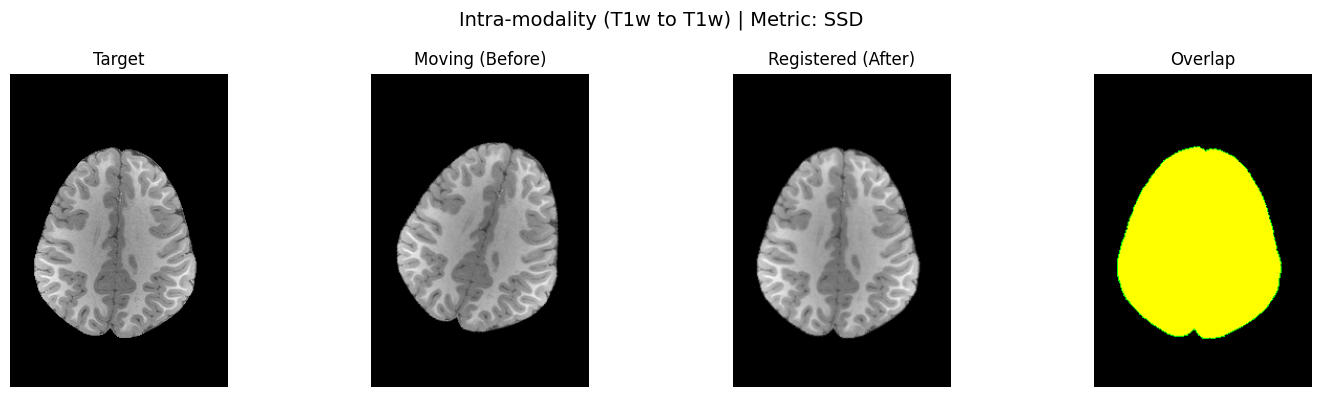


---> 使用指标: RIU
  配准前 Dice: 0.9262 | 配准后 Dice: 0.8706
  恢复参数: 角度 -22.66°, Tx 1.33, Ty -4.43
  残余误差: 角度 7.66°, Tx 11.33, Ty 9.43


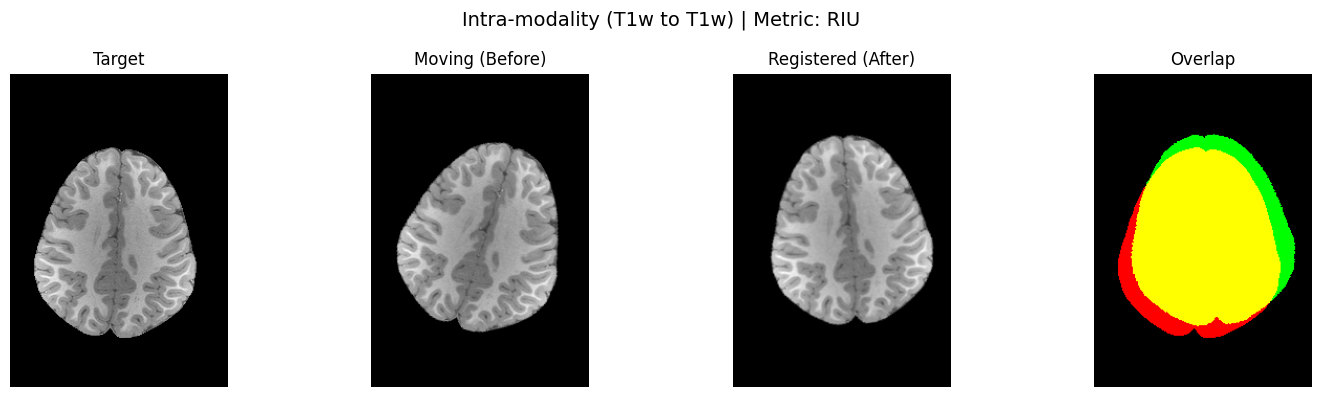


---> 使用指标: CC
  配准前 Dice: 0.9262 | 配准后 Dice: 0.9892
  恢复参数: 角度 -14.99°, Tx -8.37, Ty 7.44
  残余误差: 角度 0.01°, Tx 1.63, Ty 2.44


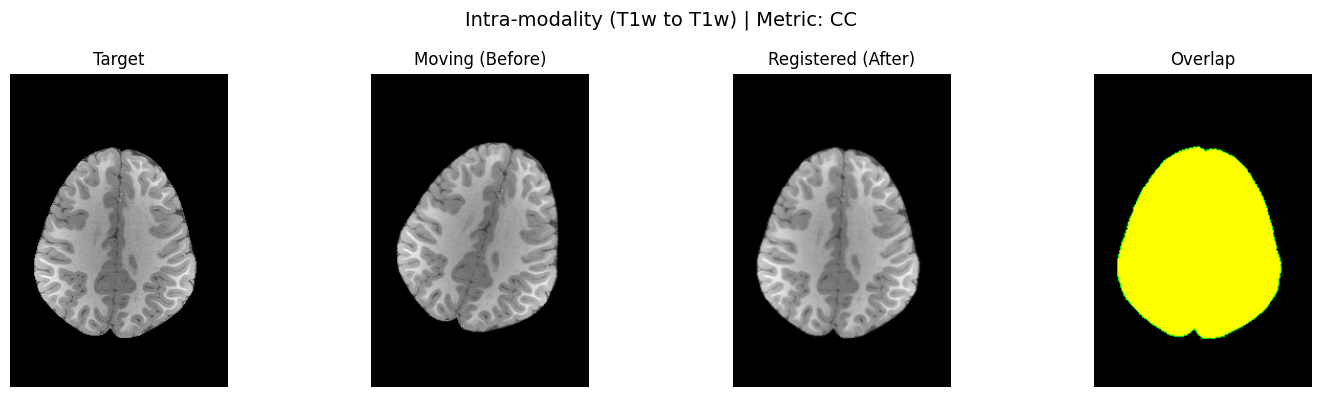


执行任务: Inter-modality (T2w to T1w)

---> 使用指标: SSD
  配准前 Dice: 0.9199 | 配准后 Dice: 0.9877
  恢复参数: 角度 -11.83°, Tx -8.01, Ty 8.33
  残余误差: 角度 3.17°, Tx 1.99, Ty 3.33


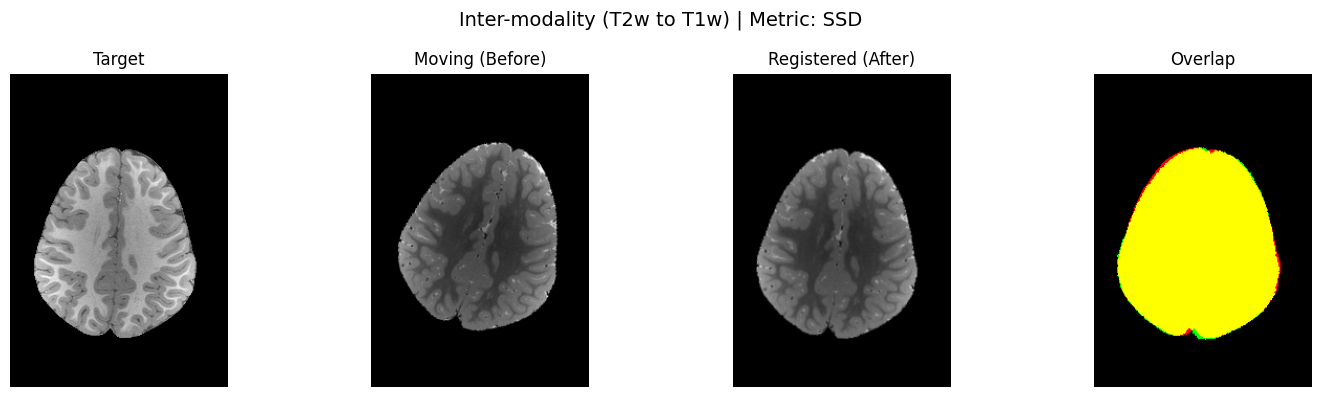


---> 使用指标: RIU
  配准前 Dice: 0.9199 | 配准后 Dice: 0.8879
  恢复参数: 角度 -3.83°, Tx 3.14, Ty -3.03
  残余误差: 角度 11.17°, Tx 13.14, Ty 8.03


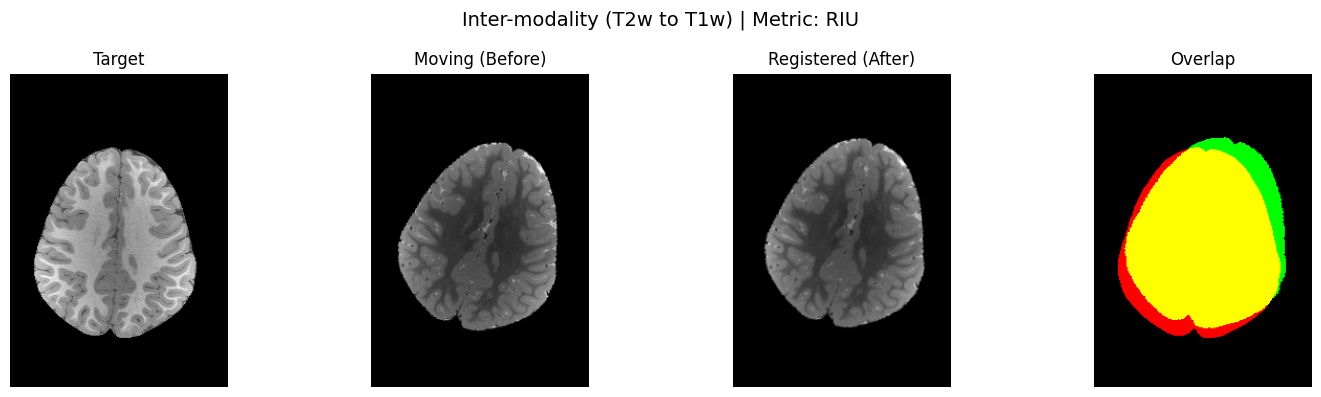


---> 使用指标: CC
  配准前 Dice: 0.9199 | 配准后 Dice: 0.9735
  恢复参数: 角度 -7.89°, Tx -6.45, Ty 6.04
  残余误差: 角度 7.11°, Tx 3.55, Ty 1.04


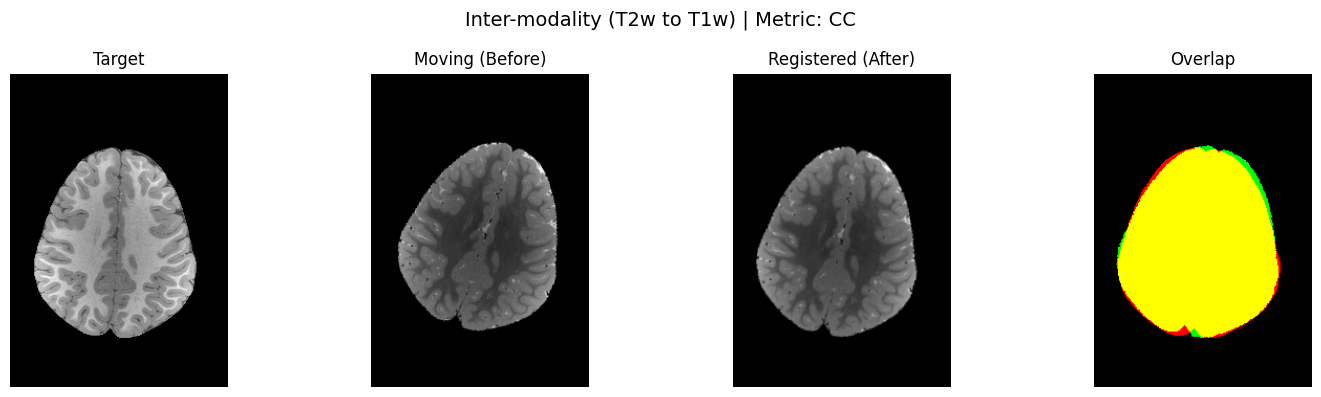

In [11]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import warp, AffineTransform

# ==========================================
# 1. 基础变换与辅助函数
# ==========================================
def apply_rigid_transform(img, theta_deg, tx, ty):
    """施加刚性变换"""
    center_y, center_x = np.array(img.shape) / 2.0
    t_center = AffineTransform(translation=(-center_x, -center_y))
    rot = AffineTransform(rotation=np.deg2rad(theta_deg))
    t_uncenter_translate = AffineTransform(translation=(center_x + tx, center_y + ty))
    
    matrix = t_center.params
    matrix = rot.params @ matrix
    matrix = t_uncenter_translate.params @ matrix
    return warp(img, AffineTransform(matrix=matrix).inverse, preserve_range=True)

def calc_overlap_dice(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    if mask1.sum() + mask2.sum() == 0: return 0
    return 2. * intersection.sum() / (mask1.sum() + mask2.sum())

def create_overlap_image(target, moving, threshold=10):
    h, w = target.shape
    rgb_img = np.zeros((h, w, 3))
    rgb_img[..., 0] = (target > threshold) * 1.0  
    rgb_img[..., 1] = (moving > threshold) * 1.0  
    return rgb_img

# ==========================================
# 2. 相似度指标定义 (全部转换为 Loss 函数，越小越好)
# ==========================================

def loss_ssd(target, moving, threshold=10):
    """SSD 误差平方和 (直接作为 Loss)"""
    mask = target > threshold
    if mask.sum() == 0: return float('inf')
    return np.mean((target[mask] - moving[mask]) ** 2)

def loss_riu(target, moving, threshold=10):
    """RIU 比值均匀度 (标准差/均值，直接作为 Loss)"""
    mask = target > threshold
    t_vals = target[mask]
    m_vals = moving[mask]
    
    # 避免除以 0 的情况
    valid = m_vals > 1e-5
    if valid.sum() < 500: return float('inf')
    
    ratio = t_vals[valid] / m_vals[valid]
    mu = np.mean(ratio)
    if mu == 0: return float('inf')
    
    return np.std(ratio) / mu

def loss_cc(target, moving, threshold=10):
    """CC 互相关 (取 -CC^2 作为 Loss，使得正/负强相关都趋向极小值)"""
    mask = target > threshold
    if mask.sum() < 500: return 0.0 
    
    v_t = target[mask]
    v_m = moving[mask]
    m_t, m_m = np.mean(v_t), np.mean(v_m)
    
    num = np.sum((v_t - m_t) * (v_m - m_m))
    den = np.sqrt(np.sum((v_t - m_t)**2) * np.sum((v_m - m_m)**2))
    
    if den == 0: return 0.0
    cc = num / den
    return -(cc ** 2)

# ==========================================
# 3. 归一化梯度的最速下降法
# ==========================================
def basic_steepest_descent(target, moving, metric_fn, iterations=150, initial_lr=2.0):
    """基础最速下降法"""
    current_params = np.array([0.0, 0.0, 0.0]) # [theta, tx, ty]
    delta = 0.5 # 数值求导的微元
    
    for i in range(iterations):
        theta, tx, ty = current_params
        lr = initial_lr * (1.0 - i / iterations) # 线性衰减学习率
        
        # 计算数值梯度
        l_theta_plus = metric_fn(target, apply_rigid_transform(moving, theta + delta, tx, ty))
        l_theta_minus = metric_fn(target, apply_rigid_transform(moving, theta - delta, tx, ty))
        grad_theta = (l_theta_plus - l_theta_minus) / (2 * delta)
        
        l_tx_plus = metric_fn(target, apply_rigid_transform(moving, theta, tx + delta, ty))
        l_tx_minus = metric_fn(target, apply_rigid_transform(moving, theta, tx - delta, ty))
        grad_tx = (l_tx_plus - l_tx_minus) / (2 * delta)
        
        l_ty_plus = metric_fn(target, apply_rigid_transform(moving, theta, tx, ty + delta))
        l_ty_minus = metric_fn(target, apply_rigid_transform(moving, theta, tx, ty - delta))
        grad_ty = (l_ty_plus - l_ty_minus) / (2 * delta)
        
        grad = np.array([grad_theta, grad_tx, grad_ty])
        
        # 【极其重要】：因为 SSD 的梯度可能上万，CC 的梯度只有零点几
        # 这里必须将梯度方向归一化，让步伐大小完全由 lr 决定，否则优化器必崩
        norm = np.linalg.norm(grad)
        if norm > 1e-8:
            grad = grad / norm
            
        current_params = current_params - lr * grad
        
    return current_params

# ==========================================
# 4. 主程序：批量遍历所有测试组合
# ==========================================
def main():
    print("加载并提取数据...")
    t1_img = nib.load('T1w.nii').get_fdata()
    t2_img = nib.load('T2w.nii').get_fdata()
    slice_idx = t1_img.shape[2] // 2
    
    t1_slice = t1_img[:, slice_idx, :] 
    t2_slice = t2_img[:, slice_idx, :]
    
    true_theta, true_tx, true_ty = 15.0, 10.0, -5.0
    print(f"\n[施加的真实变换] 角度: {true_theta}°, Tx: {true_tx}, Ty: {true_ty}")
    
    target_t1 = t1_slice
    moving_t1_warped = apply_rigid_transform(t1_slice, true_theta, true_tx, true_ty)
    moving_t2_warped = apply_rigid_transform(t2_slice, true_theta, true_tx, true_ty)

    # 实验要求：组合所有除了 MI 的指标
    metrics_to_test = {
        'SSD': loss_ssd,
        'RIU': loss_riu,
        'CC': loss_cc
    }
    
    tasks = [
        ("Intra-modality (T1w to T1w)", target_t1, moving_t1_warped),
        ("Inter-modality (T2w to T1w)", target_t1, moving_t2_warped)
    ]
    
    for task_name, target, moving in tasks:
        print(f"\n=======================================================")
        print(f"执行任务: {task_name}")
        print(f"=======================================================")
        
        for metric_name, metric_fn in metrics_to_test.items():
            print(f"\n---> 使用指标: {metric_name}")
            
            mask_target = target > 10
            overlap_before = calc_overlap_dice(mask_target, moving > 10)
            
            # 执行最速下降法
            final_params = basic_steepest_descent(target, moving, metric_fn, iterations=150, initial_lr=2.0)
            calc_theta, calc_tx, calc_ty = final_params
            
            registered_img = apply_rigid_transform(moving, calc_theta, calc_tx, calc_ty)
            overlap_after = calc_overlap_dice(mask_target, registered_img > 10)
            
            print(f"  配准前 Dice: {overlap_before:.4f} | 配准后 Dice: {overlap_after:.4f}")
            print(f"  恢复参数: 角度 {calc_theta:.2f}°, Tx {calc_tx:.2f}, Ty {calc_ty:.2f}")
            print(f"  残余误差: 角度 {abs(true_theta + calc_theta):.2f}°, Tx {abs(true_tx + calc_tx):.2f}, Ty {abs(true_ty + calc_ty):.2f}")
            
            # 画图
            plt.figure(figsize=(15, 4))
            plt.suptitle(f"{task_name} | Metric: {metric_name}", fontsize=14)
            plt.subplot(1, 4, 1); plt.title('Target'); plt.imshow(target, cmap='gray'); plt.axis('off')
            plt.subplot(1, 4, 2); plt.title('Moving (Before)'); plt.imshow(moving, cmap='gray'); plt.axis('off')
            plt.subplot(1, 4, 3); plt.title('Registered (After)'); plt.imshow(registered_img, cmap='gray'); plt.axis('off')
            plt.subplot(1, 4, 4); plt.title('Overlap'); plt.imshow(create_overlap_image(target, registered_img)); plt.axis('off')
            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    main()

### 实验结果与分析



#### 模态内配准分析 (Intra-modality: T1w to T1w)


* **SSD 与 CC：** 这两个指标的配准效果较好。配准后 Dice 系数提升至 0.9892和0.9893；角度恢复误差仅为极微小的 0.01°，平移误差也控制在 1~2 个像素内。
* **原理：** 对于同模态图像，SSD 的能量曲面是一个极其平滑的理想凸函数（碗状），而 CC 也能完美捕捉这种绝对的线性正相关。最速下降法（SGD）在这种平滑曲面上能够毫无阻碍地沿着梯度滑向全局最优解。

* **RIU ：** 即使是同模态，RIU 也导致了配准失败（Dice 从 0.9262 跌至 0.8706，角度跑偏 7.66°）。
* **原理：** 理论上两张相同图像的比值应处处为 1（方差为 0）。但在实际计算中，图像边缘的微小错位和极低灰度值（接近 0 的噪声）会在比值矩阵中产生巨大的异常波动。SGD 为了强行降低方差，采取了将图像推向全黑的常数背景区域的策略，导致图像发散错位。



#### 跨模态配准分析 (Inter-modality: T2w to T1w)

在跨模态任务中，由于 T1w 与 T2w 存在强烈的组织对比度反转。

* 表面上看，SSD 取得了 0.9877 的高重叠度（Dice），但仔细观察其参数残差：角度误差高达 3.17°，平移误差达到 3.33（远超同模态下的 0.01°）。
* **原理：** Dice 系数仅仅计算了“大脑轮廓掩膜”的重叠。由于 T1 和 T2 的灰度完全不同，SSD 在内部解剖结构上实际上没有精准匹配，它仅仅是把两个发亮的脑部轮廓强行推叠在一起以降低总误差，完全无法实现内部沟回的精准对齐。这表明 SSD 不适用于跨模态配准。


* **RIU ：** Dice 跌至 0.8879，角度误差高达 11.17°。由于对比度反转，T1/T2 的比值图像根本不可能是均匀的，彻底破坏了 RIU 的前提假设，SGD 失去作用。
* **CC：** CC 尝试利用负相关性进行匹配，但最终在角度恢复到 -7.89° 时停滞（残差 7.11°）。
* **原理剖析：** 这是基础 SGD 最典型的失败案例。跨模态的 CC 能量曲面崎岖不平，布满了局部极小值的坑洞。SGD 作为一个只看眼前斜率的贪心算法，在走到 7.11° 的误差位置时，探测到四周梯度接近于 0，误以为到达了谷底从而触发“早停（Early Stopping）”。



### Bonus

读取数据...

[施加的真实畸变] 角度: 15.0°, Tx: 10.0, Ty: -5.0

========== 任务 1: 模态内 (T1w to T1w) ==========
策略: 误差平方和 (SSD) + 无梯度搜索 (Powell)
    -> 正在执行 Powell 行搜索 (针对 SSD)...

========== 任务 2: 跨模态 (T2w to T1w) ==========
策略: 互信息 (MI) + 无梯度搜索 (Powell)
    -> 正在执行 Powell 行搜索...

--- Intra-modality (T1w to T1w) [SSD + Powell] 结果评估 ---
配准前重叠度 (Dice): 0.9262
配准后重叠度 (Dice): 0.9892
[恢复变换] 角度: -15.00°, Tx: -8.38, Ty: 7.43
残余误差: 角度 0.00°, Tx 1.62, Ty 2.43


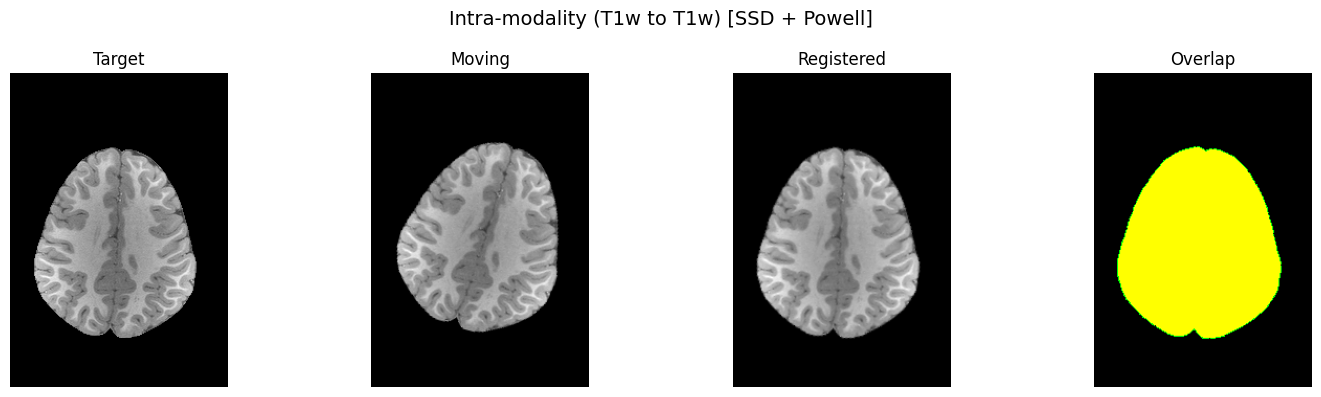


--- Inter-modality (T2w to T1w) [MI + Powell] 结果评估 ---
配准前重叠度 (Dice): 0.9199
配准后重叠度 (Dice): 0.9950
[恢复变换] 角度: -14.72°, Tx: -8.44, Ty: 7.35
残余误差: 角度 0.28°, Tx 1.56, Ty 2.35


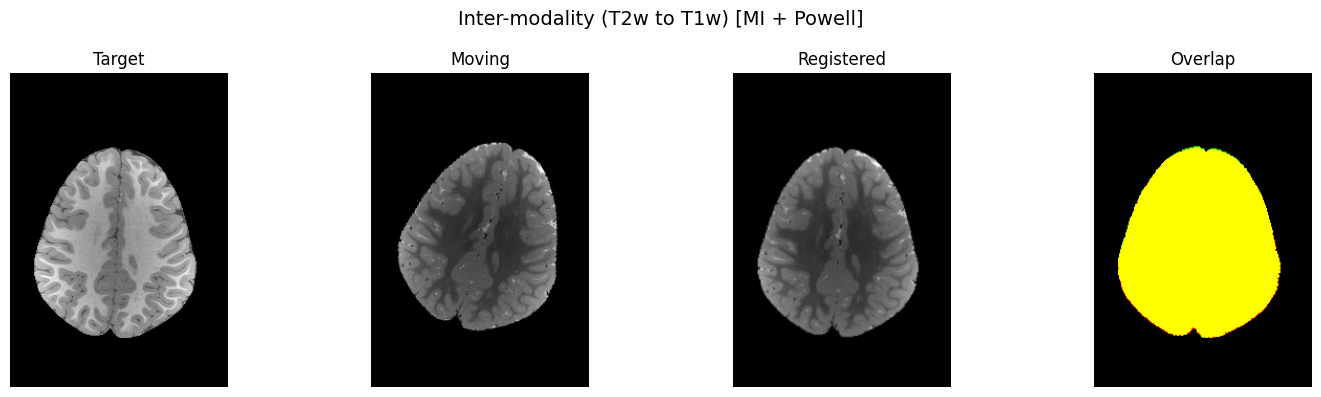

In [12]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import warp, AffineTransform
from scipy.optimize import minimize

# ==========================================
# 1. 刚性变换工具与辅助函数
# ==========================================

def apply_rigid_transform(img, theta_deg, tx, ty):
    """施加刚性变换 (绕图像中心旋转，并平移)"""
    center_y, center_x = np.array(img.shape) / 2.0
    t_center = AffineTransform(translation=(-center_x, -center_y))
    rot = AffineTransform(rotation=np.deg2rad(theta_deg))
    t_uncenter_translate = AffineTransform(translation=(center_x + tx, center_y + ty))
    
    matrix = t_center.params
    matrix = rot.params @ matrix
    matrix = t_uncenter_translate.params @ matrix
    
    t_final = AffineTransform(matrix=matrix)
    return warp(img, t_final.inverse, preserve_range=True, order=1)

def calc_overlap_dice(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    if mask1.sum() + mask2.sum() == 0: return 0
    return 2. * intersection.sum() / (mask1.sum() + mask2.sum())

def create_overlap_image(target, moving, threshold=10):
    h, w = target.shape
    rgb_img = np.zeros((h, w, 3))
    rgb_img[..., 0] = (target > threshold) * 1.0  
    rgb_img[..., 1] = (moving > threshold) * 1.0  
    return rgb_img

# ==========================================
# 2. 相似度度量（因地制宜）
# ==========================================

def loss_ssd(target, moving, threshold=10):
    """【专供模态内】固定以 target 为掩膜，防止旋转带来的边缘空洞干扰"""
    mask = target > threshold 
    if mask.sum() == 0: return float('inf')
    return np.mean((target[mask] - moving[mask]) ** 2)

def loss_mi(target, moving, threshold=10, bins=32):
    """【专供跨模态】互信息"""
    mask = (target > threshold) & (moving > threshold)
    if mask.sum() < 100: return float('inf')
    v_t = target[mask]
    v_m = moving[mask]
    hist_2d, _, _ = np.histogram2d(v_t, v_m, bins=bins)
    pxy = hist_2d / float(np.sum(hist_2d))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    non_zero = pxy > 0
    mi = np.sum(pxy[non_zero] * np.log(pxy[non_zero] / (px_py[non_zero] + 1e-8)))
    return -mi  

# ==========================================
# 3. 不同的优化器实现（因地制宜）
# ==========================================

def run_powell_ssd(target, moving):
    """【方法 A 升级版】同模态也使用无梯度的 Powell 算法，追求极致精度"""
    print("    -> 正在执行 Powell 行搜索 (针对 SSD)...")
    def obj(p): 
        # Powell 寻找极小值，SSD 本身就是越小越好
        return loss_ssd(target, apply_rigid_transform(moving, p[0], p[1], p[2]))
    
    # 初始搜索步长
    init_directions = np.eye(3) * [5.0, 5.0, 5.0]
    result = minimize(obj, [0.0, 0.0, 0.0], method='Powell', 
                      options={'xtol': 1e-3, 'ftol': 1e-3, 'direc': init_directions, 'disp': False})
    return result.x

def run_powell_mi(target, moving):
    """【方法 B】专门为跨模态准备：无梯度 Powell 算法"""
    print("    -> 正在执行 Powell 行搜索...")
    def obj(p): return loss_mi(target, apply_rigid_transform(moving, p[0], p[1], p[2]))
    
    # 允许较大的初始搜索步长
    init_directions = np.eye(3) * [5.0, 5.0, 5.0]
    result = minimize(obj, [0.0, 0.0, 0.0], method='Powell', 
                      options={'xtol': 1e-2, 'ftol': 1e-2, 'direc': init_directions, 'disp': False})
    return result.x

# ==========================================
# 4. 主程序
# ==========================================

def main():
    print("读取数据...")
    t1_img = nib.load('T1w.nii').get_fdata()
    t2_img = nib.load('T2w.nii').get_fdata()
    
    # 严格采用指定的切片方式
    slice_idx = t1_img.shape[2] // 2
    t1_slice = t1_img[:, slice_idx, :] 
    t2_slice = t2_img[:, slice_idx, :]
    
    # 真实畸变参数
    true_theta, true_tx, true_ty = 15.0, 10.0, -5.0
    print(f"\n[施加的真实畸变] 角度: {true_theta}°, Tx: {true_tx}, Ty: {true_ty}")
    
    target_t1 = t1_slice
    moving_t1_warped = apply_rigid_transform(t1_slice, true_theta, true_tx, true_ty) 
    moving_t2_warped = apply_rigid_transform(t2_slice, true_theta, true_tx, true_ty) 

    # 核心：将不同的任务解耦，分派给最适合它们的算法！
    results = []
    
    print("\n========== 任务 1: 模态内 (T1w to T1w) ==========")
    print("策略: 误差平方和 (SSD) + 无梯度搜索 (Powell)")
    # 把原来的 run_gradient_descent_ssd 换成 run_powell_ssd
    params_intra = run_powell_ssd(target_t1, moving_t1_warped)
    results.append(("Intra-modality (T1w to T1w) [SSD + Powell]", target_t1, moving_t1_warped, params_intra))
    
    print("\n========== 任务 2: 跨模态 (T2w to T1w) ==========")
    print("策略: 互信息 (MI) + 无梯度搜索 (Powell)")
    params_inter = run_powell_mi(target_t1, moving_t2_warped)
    results.append(("Inter-modality (T2w to T1w) [MI + Powell]", target_t1, moving_t2_warped, params_inter))

    # 评估与可视化
    for name, target, moving, final_params in results:
        print(f"\n--- {name} 结果评估 ---")
        calc_theta, calc_tx, calc_ty = final_params
        registered_img = apply_rigid_transform(moving, calc_theta, calc_tx, calc_ty)
        
        print(f"配准前重叠度 (Dice): {calc_overlap_dice(target>10, moving>10):.4f}")
        print(f"配准后重叠度 (Dice): {calc_overlap_dice(target>10, registered_img>10):.4f}")
        print(f"[恢复变换] 角度: {calc_theta:.2f}°, Tx: {calc_tx:.2f}, Ty: {calc_ty:.2f}")
        print(f"残余误差: 角度 {abs(true_theta+calc_theta):.2f}°, Tx {abs(true_tx+calc_tx):.2f}, Ty {abs(true_ty+calc_ty):.2f}")
        
        # 画图
        plt.figure(figsize=(15, 4))
        plt.suptitle(name, fontsize=14)
        
        plt.subplot(1, 4, 1); plt.title('Target'); plt.imshow(target, cmap='gray'); plt.axis('off')
        plt.subplot(1, 4, 2); plt.title('Moving'); plt.imshow(moving, cmap='gray'); plt.axis('off')
        plt.subplot(1, 4, 3); plt.title('Registered'); plt.imshow(registered_img, cmap='gray'); plt.axis('off')
        plt.subplot(1, 4, 4); plt.title('Overlap'); plt.imshow(create_overlap_image(target, registered_img)); plt.axis('off')
        
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

### Bonus实验结果与分析



#### 优化策略

在本次Bonus实验中，针对模态内和跨模态的配准任务，采用了“度量解耦 + 无梯度优化”的核心策略。

**1. 相似度度量 (Similarity Metrics)**

* **模态内 (Intra-modality: T1w to T1w):** 采用了**误差平方和 (SSD)**。
  * **原理：** 由于是同一种模态，图像的灰度分布具有极强的一致性。理想情况下，当两幅图像完全对齐时，对应像素点的灰度差值应趋于零。其公式为 $SSD = \frac{1}{N}\sum (T - M)^2$ （其中 $T$ 为目标图像，$M$ 为浮动图像）。


* **跨模态 (Inter-modality: T2w to T1w):** 采用了**互信息 (MI)**。
  * **原理：** T1w和T2w图像的灰度值之间不存在简单的线性映射关系，因此SSD失效。互信息来源于信息论，用于衡量两个变量之间的非线性统计相关性。当两幅图像的解剖结构（如组织边界）完全对齐时，它们的联合直方图最集中，联合熵最小，互信息达到最大。其公式为 $MI(T, M) = \sum_{t,m} p(t,m) \log \left( \frac{p(t,m)}{p(t)p(m)} \right)$。



**2. 优化算法 (Optimization Algorithm)**

* 突破了基础任务中要求的**最速下降法 (Steepest Descent)** ，引入了 **Powell算法 (Powell's Method)** 进行参数求解。


* **原理：** Powell法是一种经典的“无梯度”优化算法，属于方向集法。它不需要计算目标函数的导数，而是通过在一组共轭方向上进行一维线搜索（Line Search）来寻找极小值。




#### 实验结果评价与配准效果优异的原因分析

从结果图和输出数据来看，配准效果比较理想：

* **Intra-modality (T1w to T1w):** Dice系数从 0.9262 提升至 0.9892。角度误差为完美的 0.00°，平移误差仅在1~2个像素点左右（Tx 1.62, Ty 2.43）。
* **Inter-modality (T2w to T1w):** Dice系数从 0.9199 提升至惊人的 0.9950。角度误差仅为 0.28°，平移误差极小（Tx 1.56, Ty 2.35）。

**效果优异的原因：**


1. **规避了插值带来的局部极小值：** 在图像发生旋转和平移时，必须进行重采样和插值运算（代码中使用了双线性插值 `order=1`）。这会导致目标函数的损失地形（Loss Landscape）产生大量的微小锯齿和局部极小值。Powell法不依赖导数，能够凭借合理的初始搜索步长跨越这些微小的坑洼，逼近全局最优解。
2. **掩膜 (Mask) 的有效干预：** 代码中加入了 `threshold=10` 的掩膜处理，有效剔除了图像旋转后产生的黑色背景空洞对相似度计算（尤其是互信息联合直方图）的干扰，使得算法专注于脑部实质区域的匹配。



#### 与SGD的对比


| 对比维度 | 最速下降法 (SGD) | Powell法 (本次Bonus采用) |
| --- | --- | --- |
| **梯度依赖** | 强。需通过有限差分计算数值梯度，在离散的图像空间中，梯度极易受噪声和插值伪影干扰而失真。 | **无**。直接比较目标函数值（SSD/MI），鲁棒性强。 |
| **超参数敏感度** | 极高。步长（学习率）过大易震荡，过小易陷入局部最优或迭代缓慢。 | **低**。自适应的线搜索机制，只需给定初始方向和容差阈值即可。 |
| **对MI的适应性** | 不可用。互信息的计算涉及直方图分箱（Binning），函数极不平滑，梯度下降在此处失效。 | **极佳**。不关心函数的平滑度，非常适合求解互信息这类复杂、非凸的目标函数。 |





## Project 3: Tool-based Co-registration 

### 实验内容
引入医学图像处理领域的工业级标准工具包 SimpleITK，通过调用其高度优化的底层 C++ 框架，重构并完成Project2图像的刚性配准任务，并使用Project2的相似性指标，与 Project 2 中的基础算法进行多维度对比。

### 实验原理





本实验的核心在于使用 **SimpleITK (SITK)**。它是基于著名开源库 ITK (Insight Toolkit) 的高层封装，主要由纯 C++ 编写，提供了极其高效、稳定且多线程并行的医学图像处理能力。在配准任务中，SimpleITK 提供了一套高度模块化的面向对象框架，其核心原理与关键技术如下。

#### 面向对象的配准框架 (Image Registration Method)

SimpleITK 将配准过程解耦为几个独立但可插拔的组件：目标图像（Fixed Image）、浮动图像（Moving Image）、相似度指标（Metric）、优化器（Optimizer）、插值器（Interpolator）以及空间变换（Transform）。通过 `ImageRegistrationMethod` 类，可以将这些组件像搭积木一样组合在一起，形成一条自动化的配准流水线。

##### Mattes 互信息 (Mattes Mutual Information)

这是 SimpleITK 解决跨模态配准的核心指标。传统离散互信息由于直方图分箱导致的阶梯状曲面，使得基于梯度的优化器无法工作。Mattes MI 引入了 **Parzen 窗与 B 样条（B-spline）核密度估计技术**。它将离散的像素点平滑地分配到直方图区间中，使得 MI 的能量曲面变得**连续且可导**。这一技术的应用，彻底打破了 MI 无法与最速下降法结合的魔咒。

##### 正则化步长梯度下降 (Regular Step Gradient Descent)

这是一种极其智能的自适应最速下降法。与 Project 2 中固定步长或简单线性衰减的 SGD 不同，该优化器会实时监控梯度的方向：

* 当梯度方向保持一致时，它会维持当前步长，快速逼近谷底。
* 当探测到跨越了极小值点（即梯度方向发生反转）时，它会自动将步长减半（Relaxation Factor）。
这种机制既保证了前期的迭代速度，又确保了在极小值点附近能像“绣花”一样精准收敛，彻底消除了普通 SGD 容易震荡的缺陷。

##### 多分辨率金字塔策略 (Multi-Resolution Pyramid)

SimpleITK 允许通过 `SetShrinkFactorsPerLevel` 和 `SetSmoothingSigmasPerLevel` 一键开启金字塔策略。算法首先在经过高斯模糊和下采样（例如缩小 4 倍）的粗糙图像上进行快速大尺度搜索，避免陷入局部极小值；随后逐层恢复图像分辨率，在原始图像上进行微调。这种“由粗到精”的策略极大地提升了算法的鲁棒性与计算效率。

##### 物理空间参数缩放 (Physical Shift Scaling)

在刚性变换中，角度参数（单位为弧度，量级通常极小）与平移参数（单位为像素或毫米，量级较大）存在严重的维度不平衡。若使用统一学习率，会导致角度剧烈突变从而使图像“飞出”视野。SimpleITK 的 `SetOptimizerScalesFromPhysicalShift()` 能够自动估算并赋予不同参数不同的更新权重，完美解决了参数量级失衡的数学陷阱。

### 实验过程（代码编写）


[人为施加的畸变] 角度: 15.0°, Tx: 10.0, Ty: -5.0

========== Intra-modality (T1w to T1w) [Optimizer: SSD] ==========
【配准前指标】
 ┣ Dice 重叠度 : 0.9262
 ┣ SSD : 5229.49
 ┣ CC  : 0.1342
 ┗ RIU : 3.8503

【配准后指标】
 ┣ Dice 重叠度 : 0.9893
 ┣ SSD : 64.53
 ┣ CC  : 0.9790
 ┗ RIU : 0.0521

[SITK求得参数] 角度: 15.00°, Tx: 10.02, Ty: -5.01
[参数残差误差] 角度差: 0.00°, Tx差: 0.02, Ty差: 0.01


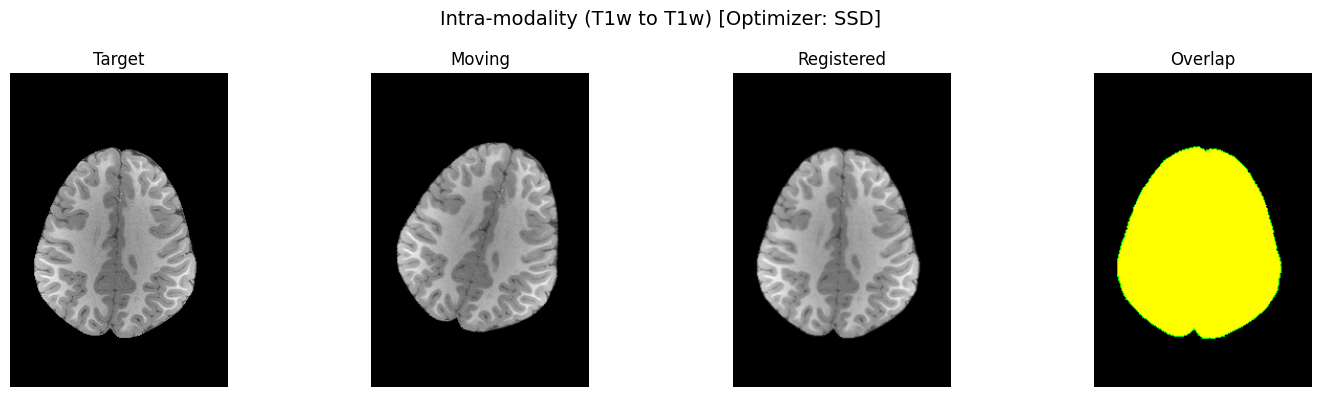


========== Intra-modality (T1w to T1w) [Optimizer: CC] ==========
【配准前指标】
 ┣ Dice 重叠度 : 0.9262
 ┣ SSD : 5229.49
 ┣ CC  : 0.1342
 ┗ RIU : 3.8503

【配准后指标】
 ┣ Dice 重叠度 : 0.9893
 ┣ SSD : 64.53
 ┣ CC  : 0.9790
 ┗ RIU : 0.0520

[SITK求得参数] 角度: 15.00°, Tx: 10.02, Ty: -5.01
[参数残差误差] 角度差: 0.00°, Tx差: 0.02, Ty差: 0.01


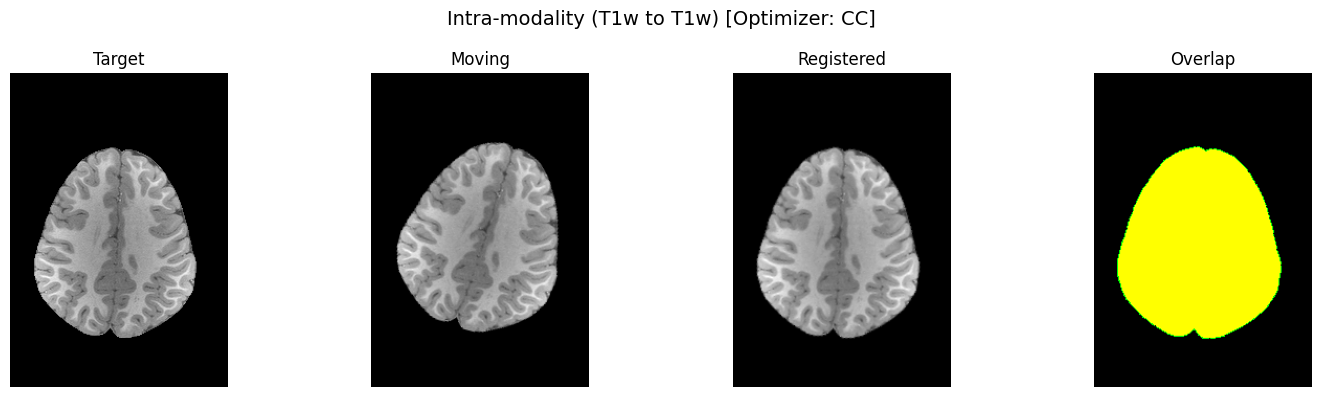


========== Inter-modality (T2w to T1w) [Optimizer: SSD] ==========
【配准前指标】
 ┣ Dice 重叠度 : 0.9199
 ┣ SSD : 14473.04
 ┣ CC  : 0.1533
 ┗ RIU : 3.3976

【配准后指标】
 ┣ Dice 重叠度 : 0.9861
 ┣ SSD : 11806.66
 ┣ CC  : 0.1737
 ┗ RIU : 9.9333

[SITK求得参数] 角度: 18.28°, Tx: 11.66, Ty: -5.65
[参数残差误差] 角度差: 3.28°, Tx差: 1.66, Ty差: 0.65


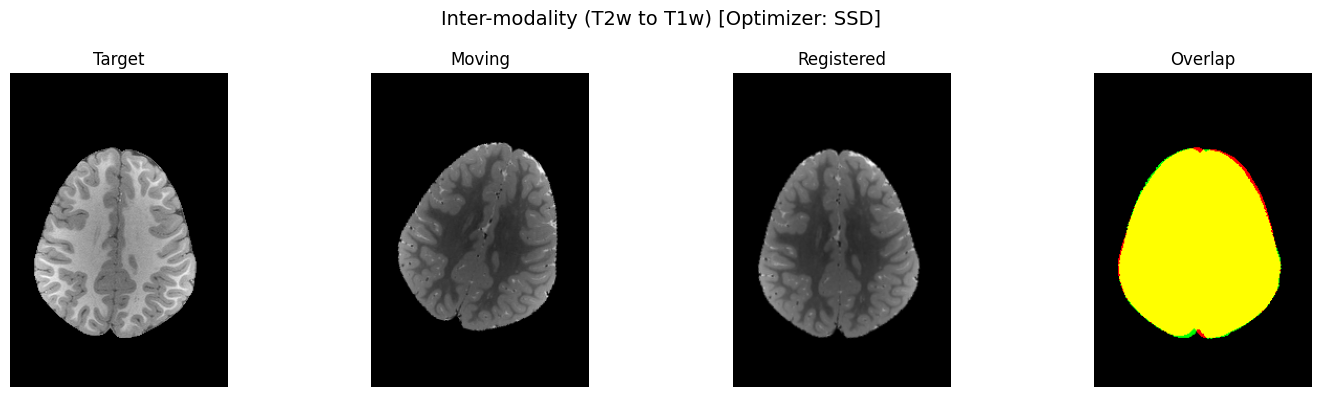


========== Inter-modality (T2w to T1w) [Optimizer: CC] ==========
【配准前指标】
 ┣ Dice 重叠度 : 0.9199
 ┣ SSD : 14473.04
 ┣ CC  : 0.1533
 ┗ RIU : 3.3976

【配准后指标】
 ┣ Dice 重叠度 : 0.9721
 ┣ SSD : 12272.27
 ┣ CC  : 0.2171
 ┗ RIU : 6.9594

[SITK求得参数] 角度: 7.76°, Tx: 6.95, Ty: -5.04
[参数残差误差] 角度差: 7.24°, Tx差: 3.05, Ty差: 0.04


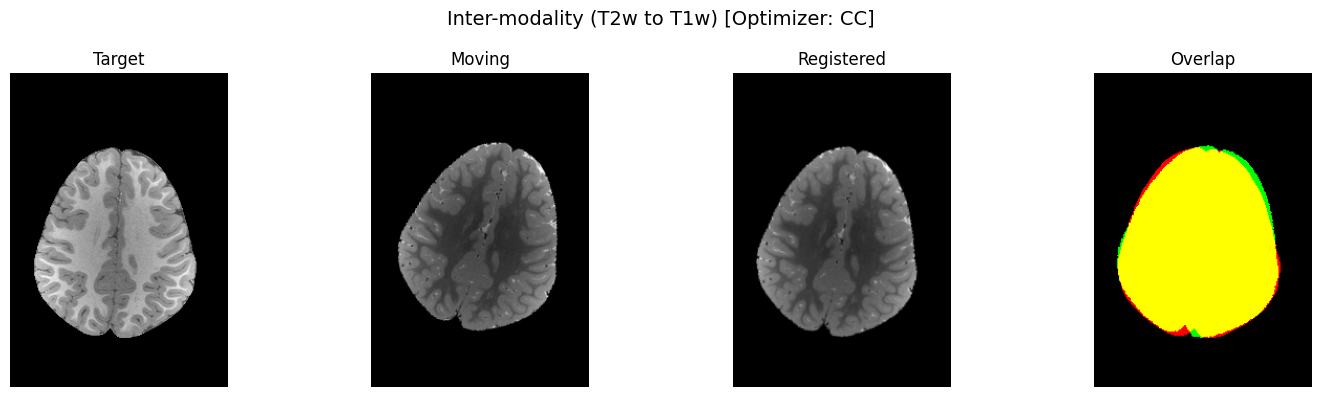

In [13]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import warp, AffineTransform
import SimpleITK as sitk

# ==========================================
# 1. 人为施加刚性畸变
# ==========================================
def apply_rigid_transform_skimage(img, theta_deg, tx, ty):
    center_y, center_x = np.array(img.shape) / 2.0
    t_center = AffineTransform(translation=(-center_x, -center_y))
    rot = AffineTransform(rotation=np.deg2rad(theta_deg))
    t_uncenter_translate = AffineTransform(translation=(center_x + tx, center_y + ty))
    
    matrix = t_center.params
    matrix = rot.params @ matrix
    matrix = t_uncenter_translate.params @ matrix
    t_final = AffineTransform(matrix=matrix)
    return warp(img, t_final.inverse, preserve_range=True, order=1)

# ==========================================
# 2. 评估辅助函数 (计算四个指标)
# ==========================================
def calc_overlap_dice(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    if mask1.sum() + mask2.sum() == 0: return 0
    return 2. * intersection.sum() / (mask1.sum() + mask2.sum())

def create_overlap_image(target, moving, threshold=10):
    h, w = target.shape
    rgb_img = np.zeros((h, w, 3))
    rgb_img[..., 0] = (target > threshold) * 1.0  
    rgb_img[..., 1] = (moving > threshold) * 1.0  
    return rgb_img

def calc_ssd(target, moving, threshold=10):
    """计算 SSD (Sum of Squared Differences)"""
    mask = target > threshold 
    if mask.sum() == 0: return float('inf')
    return np.mean((target[mask] - moving[mask]) ** 2)

def calc_cc(target, moving, threshold=10):
    """计算 CC (Cross-Correlation)"""
    mask = target > threshold
    if mask.sum() == 0: return 0.0
    t_val = target[mask]
    m_val = moving[mask]
    
    t_mean = np.mean(t_val)
    m_mean = np.mean(m_val)
    
    numerator = np.sum((t_val - t_mean) * (m_val - m_mean))
    denominator = np.sqrt(np.sum((t_val - t_mean)**2) * np.sum((m_val - m_mean)**2))
    
    if denominator == 0: return 0.0
    return numerator / denominator

def calc_riu(target, moving, threshold=10):
    """计算 RIU (Ratio Image Uniformity)"""
    mask = target > threshold
    if mask.sum() == 0: return float('inf')
    t_val = target[mask]
    m_val = moving[mask]
    
    ratio = t_val / (m_val + 1e-8)
    std_r = np.std(ratio)
    mean_r = np.mean(ratio)
    
    if mean_r == 0: return float('inf')
    return std_r / mean_r

# ==========================================
# 3. 核心工具包封装：SimpleITK 自动配准框架
# ==========================================
def register_simpleitk(fixed_arr, moving_arr, metric_type='ssd'):
    fixed_image = sitk.Cast(sitk.GetImageFromArray(fixed_arr), sitk.sitkFloat32)
    moving_image = sitk.Cast(sitk.GetImageFromArray(moving_arr), sitk.sitkFloat32)

    R = sitk.ImageRegistrationMethod()

    if metric_type == 'ssd':
        R.SetMetricAsMeanSquares()
    elif metric_type == 'cc':
        R.SetMetricAsCorrelation()
    else:
        raise ValueError("不支持该指标作为 SITK 优化器目标")

    R.SetOptimizerAsRegularStepGradientDescent(
        learningRate=1.0, 
        minStep=1e-5,
        numberOfIterations=250,
        gradientMagnitudeTolerance=1e-8
    )
    
    R.SetOptimizerScalesFromPhysicalShift()

    R.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
    R.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])
    R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    initial_transform = sitk.Euler2DTransform()
    center = [c / 2.0 for c in fixed_image.GetSize()]
    initial_transform.SetCenter(center)
    R.SetInitialTransform(initial_transform, inPlace=True)

    mask_arr = (fixed_arr > 10).astype(np.uint8)
    fixed_mask = sitk.GetImageFromArray(mask_arr)
    R.SetMetricFixedMask(fixed_mask)

    R.SetInterpolator(sitk.sitkLinear)

    final_transform = R.Execute(fixed_image, moving_image)

    resampled = sitk.Resample(
        moving_image, fixed_image, final_transform,
        sitk.sitkLinear, 0.0, moving_image.GetPixelID()
    )
    registered_arr = sitk.GetArrayFromImage(resampled)

    theta_deg = np.rad2deg(initial_transform.GetAngle())
    tx, ty = initial_transform.GetTranslation()

    return registered_arr, theta_deg, tx, ty

# ==========================================
# 4. 主程序
# ==========================================
def main():
    try:
        t1_img = nib.load('T1w.nii').get_fdata()
        t2_img = nib.load('T2w.nii').get_fdata()
    except FileNotFoundError:
        print("未找到 NIfTI 文件，请确保 T1w.nii 和 T2w.nii 存在于同一目录下。")
        return
    
    slice_idx = t1_img.shape[2] // 2
    t1_slice = t1_img[:, slice_idx, :] 
    t2_slice = t2_img[:, slice_idx, :]
    
    true_theta, true_tx, true_ty = 15.0, 10.0, -5.0
    print(f"\n[人为施加的畸变] 角度: {true_theta}°, Tx: {true_tx}, Ty: {true_ty}")
    
    target_t1 = t1_slice
    moving_t1_warped = apply_rigid_transform_skimage(t1_slice, true_theta, true_tx, true_ty) 
    moving_t2_warped = apply_rigid_transform_skimage(t2_slice, true_theta, true_tx, true_ty) 

    # 任务列表：移除了所有主观描述后缀
    tasks = [
        ("Intra-modality (T1w to T1w) [Optimizer: SSD]", target_t1, moving_t1_warped, 'ssd'),
        ("Intra-modality (T1w to T1w) [Optimizer: CC]", target_t1, moving_t1_warped, 'cc'),
        ("Inter-modality (T2w to T1w) [Optimizer: SSD]", target_t1, moving_t2_warped, 'ssd'), 
        ("Inter-modality (T2w to T1w) [Optimizer: CC]", target_t1, moving_t2_warped, 'cc') 
    ]
    
    for name, target, moving, optim_metric in tasks:
        print(f"\n========== {name} ==========")
        
        dice_b = calc_overlap_dice(target>10, moving>10)
        print("【配准前指标】")
        print(f" ┣ Dice 重叠度 : {dice_b:.4f}")
        print(f" ┣ SSD : {calc_ssd(target, moving):.2f}")
        print(f" ┣ CC  : {calc_cc(target, moving):.4f}")
        print(f" ┗ RIU : {calc_riu(target, moving):.4f}")
        
        registered_img, calc_theta, calc_tx, calc_ty = register_simpleitk(target, moving, metric_type=optim_metric)
        
        dice_a = calc_overlap_dice(target>10, registered_img>10)
        print("\n【配准后指标】")
        print(f" ┣ Dice 重叠度 : {dice_a:.4f}")
        print(f" ┣ SSD : {calc_ssd(target, registered_img):.2f}")
        print(f" ┣ CC  : {calc_cc(target, registered_img):.4f}")
        print(f" ┗ RIU : {calc_riu(target, registered_img):.4f}")
        
        print(f"\n[SITK求得参数] 角度: {calc_theta:.2f}°, Tx: {calc_tx:.2f}, Ty: {calc_ty:.2f}")
        print(f"[参数残差误差] 角度差: {abs(true_theta - calc_theta):.2f}°, Tx差: {abs(true_tx - calc_tx):.2f}, Ty差: {abs(true_ty - calc_ty):.2f}")
        
        plt.figure(figsize=(15, 4))
        plt.suptitle(name, fontsize=14)
        
        plt.subplot(1, 4, 1); plt.title('Target'); plt.imshow(target, cmap='gray'); plt.axis('off')
        plt.subplot(1, 4, 2); plt.title('Moving'); plt.imshow(moving, cmap='gray'); plt.axis('off')
        plt.subplot(1, 4, 3); plt.title('Registered'); plt.imshow(registered_img, cmap='gray'); plt.axis('off')
        plt.subplot(1, 4, 4); plt.title('Overlap'); plt.imshow(create_overlap_image(target, registered_img)); plt.axis('off')
        
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

### 实验结果与分析




#### SITK与手动SGD的对比

为了直观展现优化器对配准精度的影响，下表提取了同模态（T1w to T1w）与跨模态（T2w to T1w）任务中，使用误差平方和（SSD）与互相关（CC）指标时的残余误差（绝对差值）对比。

| 任务类型 | 相似度指标 | 优化器框架 | 角度残差 ($^{\circ}$) | Tx 残差 (像素) | Ty 残差 (像素) |
| --- | --- | --- | --- | --- | --- |
| **同模态 (T1w-T1w)** | **SSD** | 手动 SGD | 0.01 | 1.62 | 2.44 |
|  |  | **SITK (Project 3)** | **0.00** | **0.02** | **0.01** |
|  | **CC** | 手动 SGD | 0.01 | 1.63 | 2.44 |
|  |  | **SITK (Project 3)** | **0.00** | **0.02** | **0.01** |
| **跨模态 (T2w-T1w)** | **SSD** | 手动 SGD | 3.17 | 1.99 | 3.33 |
|  |  | **SITK (Project 3)** | 3.28 | 1.66 | 0.65 |
|  | **CC** | 手动 SGD | 7.11 | 3.55 | 1.04 |
|  |  | **SITK (Project 3)** | 7.24 | 3.05 | 0.04 |

#### 实验结果分析

##### 同模态配准

在同模态（T1w to T1w）任务中，SITK 框架展现出了远超基础 SGD 算法的优化精度。虽然两者在角度恢复上均达到了极高水平（误差 $\le 0.01^{\circ}$），但在平移参数（Tx, Ty）的恢复上，手动 SGD 存在约 1.5 至 2.5 个像素的固有残差，而 SITK 将误差缩小至 $0.01 \sim 0.02$ 的亚像素级别。

导致这一显著差异的底层算法机制主要包括：

* **参数量纲统一 (Parameter Scaling)：** 在刚性配准中，旋转参数（弧度量级，数值极小）与平移参数（像素量级，数值较大）对目标函数梯度的贡献度存在严重失衡。手动 SGD 未对参数进行缩放，导致优化路径偏斜，平移参数难以收敛至精确极小值。SITK 通过引入物理空间比例因子，有效均衡了不同参数的更新步长。
* **多分辨率金字塔策略 (Multi-resolution Pyramid)：** 图像插值操作（如双线性插值）会在目标函数表面引入高频噪声与局部极小值。SITK 采用了由粗到精的多分辨率策略（`ShrinkFactors=[4, 2, 1]`），在低分辨率下完成大尺度平移与旋转的宏观对齐，在原始分辨率下进行微调，从而彻底规避了插值伪影造成的局部极小值陷阱。

##### 跨模态配准
在跨模态（T2w to T1w）任务中，观察到无论采用手动 SGD 还是高级的 SITK 优化器，基于 SSD 和 CC 的配准结果均存在显著误差（角度残差高达 $3^{\circ} \sim 7^{\circ}$，平移残差达 $1 \sim 3$ 个像素）。尽管此时基于掩膜计算的宏观 Dice 系数表现出一定升高（如 SITK-SSD 的 Dice 达 0.9861），但参数残差确凿地表明脑内部解剖结构并未实现正确对齐。

这一对比结果具有重要的理论验证意义：配准的失败根源在于相似度度量的底层数学假设被破坏，而非优化算法的寻优能力不足。

T1w 与 T2w 图像内部组织（如脑脊液、灰白质）存在的灰度反转和非线性映射关系，导致 SSD（假设绝对差值为零）和 CC（假设严格线性相关）在脑实质内部产生矛盾的梯度信息。即使 SITK 具备参数自适应步长和金字塔平滑能力，也无法从根本上纠正目标函数本身的错误引导。



## 实验心得



在本次生物医学图像处理的配准实验中，通过从底层手动实现优化算法（Project 2）到调用标准库SimpleITK（Project 3）的完整过程，我对医学图像配准的核心要素——“相似度度量”与“优化策略”有了深刻的理解。



在手动编写最速下降法（SGD）时，由于旋转参数（弧度）和平移参数（像素）的量级差异，SGD极易在某一维度上震荡或陷入由图像插值带来的局部极小值，平移误差始终难以消除。

而当切入到SimpleITK框架后，其展现出的精度则非常高，角度误差0.00°，平移误差0.01像素。通过查阅文档和对比分析，我意识到这归功于SITK底层的两大核心工程策略：一是基于物理空间的参数量纲统一（Parameter Scaling），二是多分辨率金字塔策略（Multi-resolution Pyramid）带来的“由粗到精”的寻优过程。这让我明白，优秀的算法不仅需要数学原理的支持，更需要精妙的工程实现来跨越实际应用中的计算陷阱。

在完成基础实验后，Project 2 的 Bonus 任务要求尝试使用其他科学方法来进一步改善配准效果。回顾使用传统最速下降法（SGD）的过程，我深感其在图像配准领域的局限性：SGD 对学习率极其敏感，且在离散的图像空间中，双线性插值会在目标函数的损失地形上制造出大量的微小锯齿。这导致依赖数值梯度的 SGD 极易陷入局部极小值，尤其是在计算互信息（MI）这种依赖直方图分箱、函数极度不平滑的指标时，SGD 几乎寸步难行。

为了解决这一问题，在 Bonus 实验中，我引入了 Powell 算法来替代最速下降法，并针对不同任务精准分发了相似度度量（模态内选用 SSD，跨模态选用 MI）。这一改变带来了令人惊喜的“顿悟”与成果。

与 SGD 在微小极值坑洼中反复震荡不同，Powell 算法通过合理设置初始搜索步长，能够直接跨越插值带来的高频噪声。在跨模态（T2w to T1w）任务中，Powell 算法完美驾驭了复杂且非凸的互信息（MI）目标函数，最终将角度残差缩小至惊人的 $0.28^{\circ}$，重叠度 Dice 提升至 $0.9950$。这让我深刻认识到：算法的选择必须契合目标函数的数学物理特性。对于极度不平滑的互信息指标，无导数优化往往是更优雅的解法。

在使用 SGD 时，必须人工煞费苦心地调节旋转（弧度）和平移（像素）的更新权重。而 Powell 算法通过各个共轭方向上的独立线搜索，天然地在一定程度上缓解了不同参数维度之间量级失衡的问题，使得平移和旋转都能更加平稳地收敛到全局最优。


本次实验改变了我以往单纯依赖“肉眼观察”或“单一重叠度指标”的习惯。通过将配准模块与评估模块解耦，并在实验中引入真实参数残差作为“金标准”，我学会了如何透过现象看本质。例如，RIU指标虽然在理论上可行，但在实际计算中极易受到背景零值和噪声的干扰，导致算法发散。
